# 1 Reading Dataset

In [99]:
# import library and read dataset
import pandas as pd
df_reviews = pd.read_csv('IMDB Dataset.csv', engine = 'python')
df_reviews

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [100]:
# take a sample of 10000 rows to make processing faster and get imbalance data

# 9000 positive sentiment
df_positive = df_reviews[df_reviews['sentiment'] == 'positive'][:9000]

# 1000 negative sentiment
df_negative = df_reviews[df_reviews['sentiment'] == 'negative'][:1000]

In [101]:
# concatenate dataframes
df_reviews_imb = pd.concat([df_positive, df_negative])
df_reviews_imb['sentiment'].value_counts()

#imbalance because number of observation in a class are not equally distributed

,count
sentiment,
positive,9000
negative,1000


# 2 Dealing with Imbalanced Classes

<Axes: xlabel='sentiment'>

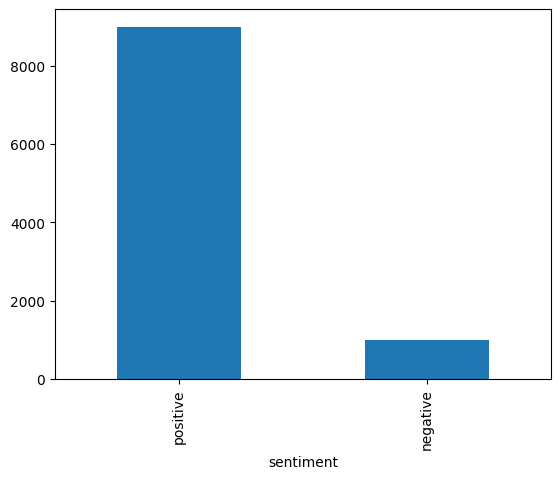

In [102]:
# make a bar plot to show how data is distributed
df_reviews_imb.value_counts('sentiment').plot(kind = 'bar')

## 2.1 Balancing data with .sample()
* undersampling

In [103]:
# as we are undersampling positive reviews, therefor we need the length of negative reviews
length_negative = len(df_reviews_imb[df_reviews_imb['sentiment'] == 'negative'])
length_negative

1000

In [104]:
df_reviews_positive = (df_reviews_imb[df_reviews_imb['sentiment'] == 'positive']).sample(n=1000)
df_reviews_negative = df_reviews_imb[df_reviews_imb['sentiment'] == 'negative']

In [105]:
# concatenate both dataframes
pd.concat([df_reviews_positive, df_reviews_negative])

,review,sentiment
3253,"The plot of ""In the Mood for Love"" is simple e...",positive
9240,This event defined an era of wrestling enterta...,positive
6011,I have seen Maslin Beach a couple of times - b...,positive
7689,"This is an incredibly compelling story, told w...",positive
3430,It's a mistake to refer to any film of this er...,positive
...,...,...
2000,Stranded in Space (1972) MST3K version - a ver...,negative
2005,"I happened to catch this supposed ""horror"" fli...",negative
2007,waste of 1h45 this nasty little film is one to...,negative
2010,Warning: This could spoil your movie. Watch it...,negative


In [106]:
# creating balanced dataframe
pd.concat([df_reviews_positive, df_reviews_negative]).value_counts('sentiment')
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])
df_reviews_bal.reset_index(drop = True, inplace = True)
df_reviews_bal

,review,sentiment
0,"The plot of ""In the Mood for Love"" is simple e...",positive
1,This event defined an era of wrestling enterta...,positive
2,I have seen Maslin Beach a couple of times - b...,positive
3,"This is an incredibly compelling story, told w...",positive
4,It's a mistake to refer to any film of this er...,positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


## 2.2 Balancing data with RandomUnderSampler

In [107]:
# installing the library
# !pip install imblearn

In [108]:
from imblearn.under_sampling import RandomUnderSampler

#creating instance of RandomUnderSampler
rus = RandomUnderSampler(random_state = 0)

# to resample the imbalanced data and the input generally should be a dataframe(2-D Array) and Series (1-D Array)
df_reviews_bal, df_reviews_bal['sentiment'] = rus.fit_resample(df_reviews_imb[['review']], df_reviews_imb['sentiment'])

In [109]:
df_reviews_bal.value_counts('sentiment') # cross-checking

,count
sentiment,
negative,1000
positive,1000


In [110]:
# to oversample, just use over instead of under in above header line

# 3 Splitting data in train and test

In [111]:
# import train_test_split
from sklearn.model_selection import train_test_split

#create train and test dataframes
train, test = train_test_split(df_reviews_bal, test_size = 0.33, random_state = 42)

In [112]:
# splitting into train_x, train_y, test_x, test_y
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [113]:
train_y.value_counts()

,count
sentiment,
negative,675
positive,665


# 4 Text Representation (Bag of Words)

## 4.1 Count Vectorizer

In [114]:
from sklearn.feature_extraction.text import CountVectorizer
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({'review' : ['review1', 'review2'],
                   'text': text})
cv = CountVectorizer(stop_words='english') # creating object and stop_words removes common words the, is, am etc
cv_matrix = cv.fit_transform(df['text']) # returns a sparse matrix (contains mostly 0, so eventually it saves memory)
cv_matrix.toarray() # converts sparse matrix into normal Numpy Array
print(cv_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 6)>
  Coords	Values
  (0, 3)	2
  (0, 5)	1
  (0, 0)	2
  (0, 4)	2
  (1, 5)	1
  (1, 0)	2
  (1, 1)	2
  (1, 2)	2


In [115]:
df_dtm = pd.DataFrame(cv_matrix.toarray(), index = df['review'].values, columns = cv.get_feature_names_out()) #document term matrix
df_dtm



,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,2,2,0,0,1


## 4.2 TF-IDF Score

In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({'review' : ['review1', 'review2'],
                   'text': text})

tfidf = TfidfVectorizer(stop_words = 'english', norm = None) #default it uses L2 normalization, but by norm=None, it uses the formula we studided
tfidf_matrix = tfidf.fit_transform(df['text'])

In [117]:
pd.DataFrame(tfidf_matrix.toarray(), index = df['review'].values, columns = tfidf.get_feature_names_out())

,code,hate,java,love,python,writing
review1,2.0,0.00000,0.00000,2.81093,2.81093,1.0
review2,2.0,2.81093,2.81093,0.00000,0.00000,1.0


# 5 Turning our text data into numerical vectors

In [118]:
from sklearn.feature_extraction.text import TfidfVectorizer

Tfidf = TfidfVectorizer(stop_words = 'english', norm = None)
# train_x has  reviews and we're gonna feed Tfidf with this
train_x_vector = Tfidf.fit_transform(train_x)


In [119]:
train_x_vector # Sparsed Matrix, 118834 are known zero values(very less percentage)
# train_x_vector.toarray() # most values are zero


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 118834 stored elements and shape (1340, 20625)>

In [120]:
test_x_vector = Tfidf.transform(test_x) # no need to use fit() as Tfidf already knows the optimat parameters
test_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 53486 stored elements and shape (660, 20625)>

In [141]:
pd.DataFrame.sparse.from_spmatrix(train_x_vector, index = train_x.index , columns = Tfidf.get_feature_names_out())


,00,000,007,01pm,02,04,08,10,100,1000,...,zooming,zooms,zues,zzzzzzzzzzzzzzzzzz,æon,élan,émigré,ísnt,ïn,ünfaithful
144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1839,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16588,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
742,0,0,0,0,0,0,0,2.948897,0,0,...,0,0,0,0,0,0,0,0,0,0
9464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16133,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2443,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 6 Model Selection

## 6.1 Support Vector Machines (SVM)

In [123]:
from sklearn.svm import SVC

svc = SVC(kernel = 'linear')
svc.fit(train_x_vector, train_y)

SVC(kernel='linear')

In [124]:
print(svc.predict(Tfidf.transform(['A good movie']))) # Tfidf transforms this text into vectors and svc is predicting sentiment based on this vector
print(svc.predict(Tfidf.transform(['An excellent movie'])))
print(svc.predict(Tfidf.transform(['I did not like this movie at all, I gave this away'])))

['positive']
['positive']
['negative']


## 6.2 Decision Tree

In [125]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector,train_y)

DecisionTreeClassifier()

 ## 6.3 Naive Bayes

In [126]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y) #unlike other models, here you haver to pass normal matrix (NumPy array)  instead of Sparse matrix

GaussianNB()

## 6.4 Logistic Regression

In [127]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)

LogisticRegression()

# 7 Model Evaluation

## 7.1 Confusion Matrix

In [147]:
# calculate confusion matrix of svc
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_y, svc.predict(test_x_vector), labels = ['positive', 'negative'])
cm

array([[282,  53],
       [ 57, 268]])

## 7.2 Mean Accuracy (from confusion matrix output)

In [150]:
# calculate accuracy of all models
print(svc.score(test_x_vector, test_y)) # test_x_vector provides an unbiased evaluation of a final model fit on the training dataset
print(dec_tree.score(test_x_vector, test_y))
print(gnb.score(test_x_vector.toarray(), test_y))
print(log_reg.score(test_x_vector, test_y))

# model.score(test_x_vector, test_y)

0.8333333333333334
0.65
0.6348484848484849
0.8348484848484848


## 7.3 F1 Score

In [160]:
from sklearn.metrics import f1_score

f1_score(test_y, svc.predict(test_x_vector), labels = ['positive','negative'], pos_label = 'positive', average = None)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got None). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


array([0.83679525, 0.82972136])

## 7.4 Classificaiton Report

In [162]:
from sklearn.metrics import classification_report

print(classification_report(test_y, svc.predict(test_x_vector), labels = ['positive','negative']))

              precision    recall  f1-score   support

    positive       0.83      0.84      0.84       335
    negative       0.83      0.82      0.83       325

    accuracy                           0.83       660
   macro avg       0.83      0.83      0.83       660
weighted avg       0.83      0.83      0.83       660



# Tuning the Model

## 8.1 GridSearchCV

In [166]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'C' : [1,4,8,16,32],
    'kernel' : ['linear', 'rbf']
}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv=5)
svc_grid.fit(train_x_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [168]:
svc_grid.best_params_ # return best hyperparameter combination

{'C': 1, 'kernel': 'linear'}

In [171]:
svc_grid.best_score_.item() # returns best avg accuracy

0.8059701492537312

In [170]:
svc_grid.best_estimator_ # returns fully trained best model

SVC(C=1, kernel='linear')